In [50]:
# 由于要实现的模型涉及到比较复杂的数据处理和分析，我们将从简单的数据探索开始，
# 然后尝试定义并计算动量指标，最后进行简单的可视化展示。
# 本例将重点放在如何根据比赛分数计算动量，并不会构建一个完整的状态空间模型。

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings 
warnings.filterwarnings('ignore')
# 读取数据
df = pd.read_csv('Wimbledon_featured_matches.csv')
# df = pd.read_excel('match1701.xlsx')

# 选择一场特定的比赛进行分析，根据题目描述选择2023年温布尔登决赛
# 假设决赛的match_id为"2023-wimbledon-1701"
match_id = "2023-wimbledon-1701"
match_data = df[df['match_id'] == match_id].copy()
match_data.reset_index(inplace=True,drop=True)  

势头可以被定义为球员当前表现的一个量度，相对于比赛中平均或预期表现的偏差。整体定义思想是：动量可以通过计算球员在特定时间窗口内相对于对手的得分优势来量化。请基于上面提供的数据，定义一个势头计算函数，尽可能全部利用数据中的指标，用于计算球员1，2各种在特定特定时间窗口内的势头，需要注意，在网球比赛中，发球方赢得分数/局的概率较高，这一点可以在模型中得到体现。

为了定义一个计算网球比赛中球员势头的函数，我们可以考虑以下几个关键指标：

1. **得分优势**：比较特定时间窗口内两位球员的得分差异。
2. **赢得的局数和盘数**：在时间窗口内，比较两位球员各自赢得的局数和盘数，更高的数值表示更大的势头。
3. **发球情况**：在网球中，发球方有较大优势。我们可以考虑发球方赢得的分数比例，以及发球方是否能够保发（即赢得自己的发球局）。
4. **破发点**：破发点赢得数量也是势头的一个重要指标，它表示球员能够在对方发球局中赢得比赛的能力。
5. **非受迫性失误**：较少的非受迫性失误可以被看作是更好的表现和更高的势头。
6. **制胜分**：制胜分的数量可以表示球员的攻击力和比赛中的主动性。

基于以上指标，我们可以定义一个简单的势头计算模型，将以上各因素加权合并。发球方优势可以通过增加发球方在该时间窗口内赢得的分数/局的权重来体现。以下是一个简化版的势头计算函数的伪代码：


这个模型是一个起点，可以根据实际情况和更深入的数据分析进行调整和优化。例如，权重的选择和其他潜在指标的加入可以进一步细化模型，以更准确地反映比赛中的势头变化。

In [51]:
# 改进势头计算函数以包括赢得的局数和盘数，以及更精确的发球优势计算
def calculate_momentum_improved(df, index, window_size=3):
    start_index = max(index - window_size, 0)
    end_index = min(index + window_size + 1, len(df))
    time_window_df = df.iloc[start_index:end_index]

    # 初始化势头值
    p1_momentum = 0
    p2_momentum = 0

    # 赢得的局数和盘数
    p1_sets_won = time_window_df['p1_sets'].iloc[-1] - time_window_df['p1_sets'].iloc[0]
    p2_sets_won = time_window_df['p2_sets'].iloc[-1] - time_window_df['p2_sets'].iloc[0]
    p1_games_won = time_window_df['p1_games'].iloc[-1] - time_window_df['p1_games'].iloc[0]
    p2_games_won = time_window_df['p2_games'].iloc[-1] - time_window_df['p2_games'].iloc[0]

    # 发球优势
    # 假设发球方在每个得分上的额外权重为0.432
    serve_advantage_weight = 0.12
    p1_serve_advantage = (time_window_df[time_window_df['server'] == 1]['point_victor'] == 1).sum() * serve_advantage_weight
    p2_serve_advantage = (time_window_df[time_window_df['server'] == 2]['point_victor'] == 2).sum() * serve_advantage_weight

    # 其他因素（得分优势、破发点、非受迫性失误、制胜分）
    p1_points_advantage = (time_window_df['point_victor'].apply(lambda x: x == 1).sum() - time_window_df['point_victor'].apply(lambda x: x == 2).sum())*0.07
    p2_points_advantage = -p1_points_advantage*0.07
    p1_break_points_won = time_window_df['p1_break_pt_won'].sum() *0.22
    p2_break_points_won = time_window_df['p2_break_pt_won'].sum() *0.22
    p1_unforced_errors = -time_window_df['p1_unf_err'].sum() * 0.1
    p2_unforced_errors = -time_window_df['p2_unf_err'].sum() * 0.09
    p1_winners = time_window_df['p1_winner'].sum() *0.08
    p2_winners = time_window_df['p2_winner'].sum() *0.12


    # 合并计算势头
    p1_momentum = p1_points_advantage + p1_serve_advantage + p1_break_points_won + p1_unforced_errors + p1_winners + p1_sets_won + p1_games_won
    p2_momentum = p2_points_advantage + p2_serve_advantage + p2_break_points_won + p2_unforced_errors + p2_winners + p2_sets_won + p2_games_won

    return p1_momentum, p2_momentum

# 对数据集中的每一行应用计算势头的函数
momentum_values = [calculate_momentum_improved(match_data, index) for index in range(len(match_data))]

momentum_values

[(0.08, 0.24),
 (0.15000000000000002, 0.1451),
 (0.08, 0.27),
 (0.009999999999999995, 0.5149),
 (0.15000000000000002, 0.3851),
 (-0.09000000000000001, 0.5149),
 (-0.31000000000000005, 0.6447),
 (-0.41000000000000003, 1.5247),
 (-0.55, 1.7445),
 (-0.6500000000000001, 1.6245),
 (-0.39000000000000007, 1.3747),
 (-0.19000000000000006, 1.3747),
 (-0.09000000000000004, 1.4747),
 (-0.19000000000000006, 1.4747),
 (0.049999999999999975, 1.3749),
 (0.19, 1.2451),
 (0.29, 1.3651),
 (0.029999999999999985, 1.4949),
 (-0.31000000000000005, 1.7447),
 (-0.31000000000000005, 1.5247),
 (0.04999999999999999, 1.3949),
 (-0.09000000000000002, 1.4947),
 (-0.33000000000000007, 1.5045),
 (-0.07000000000000003, 1.3747),
 (0.26999999999999996, 1.2449),
 (0.26999999999999996, 0.004900000000000001),
 (0.26999999999999996, 0.2249),
 (0.009999999999999967, 1.3547),
 (-0.09000000000000004, 1.4747),
 (0.22999999999999998, 1.4649),
 (-0.13000000000000003, 1.5947),
 (-0.47000000000000003, 1.8445),
 (-0.1300000000000000

In [52]:
p1_momentum=[]
p2_momentum=[]
for i in momentum_values:
    p1_momentum.append(i[0])
    p2_momentum.append(i[1])

In [53]:
# 将计算得到的势头值分配回原始数据集
match_data['p1_momentum']=pd.DataFrame(p1_momentum)
match_data['p2_momentum']=pd.DataFrame(p2_momentum)

In [54]:

# 显示更新后的数据集的前几行，包括势头值
match_data[['match_id', 'player1', 'player2', 'elapsed_time', 'p1_momentum', 'p2_momentum']].head()

,match_id,player1,player2,elapsed_time,p1_momentum,p2_momentum
0,2023-wimbledon-1701,Carlos Alcaraz,Novak Djokovic,00:00:00,0.08,0.2400
1,2023-wimbledon-1701,Carlos Alcaraz,Novak Djokovic,00:00:25,0.15,0.1451
2,2023-wimbledon-1701,Carlos Alcaraz,Novak Djokovic,00:01:19,0.08,0.2700
3,2023-wimbledon-1701,Carlos Alcaraz,Novak Djokovic,00:02:17,0.01,0.5149
4,2023-wimbledon-1701,Carlos Alcaraz,Novak Djokovic,00:03:02,0.15,0.3851


In [55]:
match_data[['match_id', 'player1', 'player2', 'elapsed_time', 'p1_momentum', 'p2_momentum']].to_csv('Q1_demo.csv',index=None)

In [56]:
import matplotlib.pyplot as plt

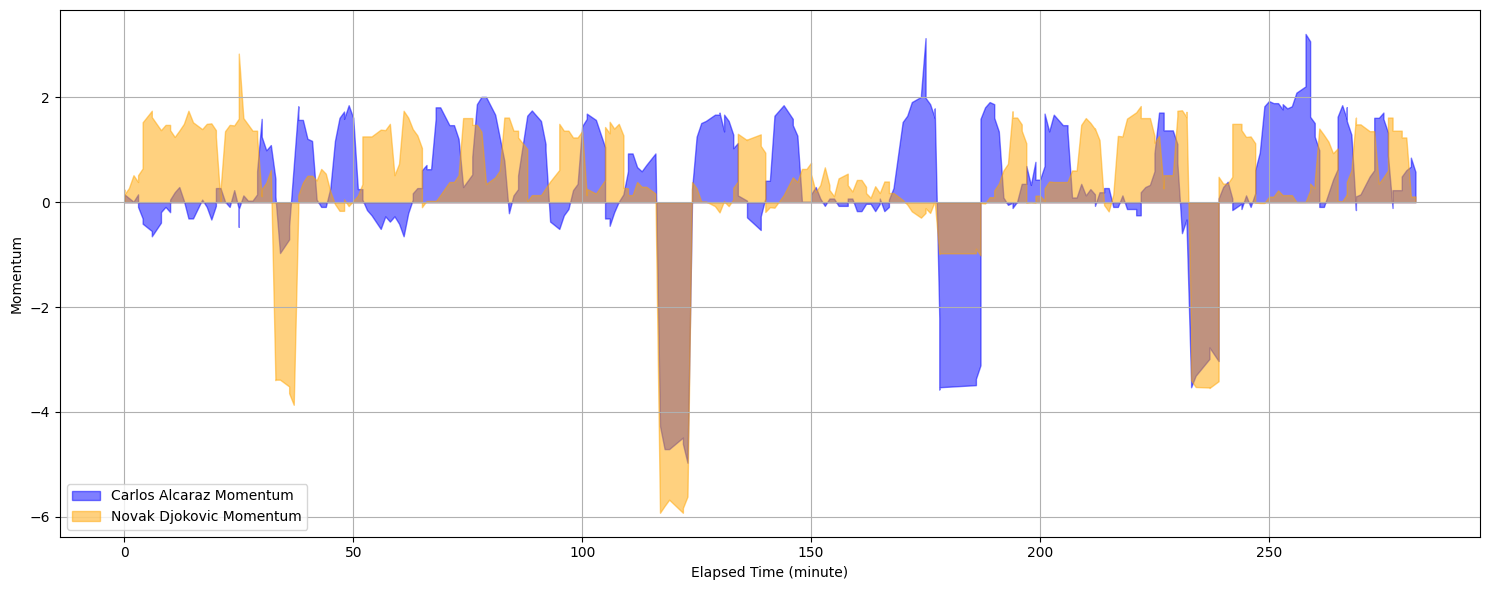

In [64]:
def cumsum_detection(series):
    """
    CUMSUM检测算法实现，用于检测序列中的转折点。
    :param series: 一维数据序列 (Pandas Series)
    :return: 转折点的索引列表
    """
    # 计算差分序列
    diff_series = series.diff().fillna(0)  # 用0填充NaN值
    
    # 计算累积和
    cumsum_series = diff_series.cumsum()
    
    # 识别转折点：当累积和重新穿过零点时，认为是一个转折点
    turning_points = []
    for i in range(1, len(cumsum_series)):
        # 如果累积和的符号与前一个不同，则认为是转折点
        if cumsum_series[i] * cumsum_series[i-1] < 0:
            turning_points.append(i)
    
    return turning_points
import matplotlib.pyplot as plt
import numpy as np

# 将 elapsed_time 转换为可比较的数值（秒）
elapsed_m = match_data['elapsed_time'].apply(lambda x: sum(int(a) * 60**index for index, a in enumerate(reversed(x.split(":"))))) //60

# 应用CUMSUM检测算法来识别两位球员势头的转折点
p1_turning_points = cumsum_detection(match_data['p1_momentum'])
p2_turning_points = cumsum_detection(match_data['p2_momentum'])

# 创建颜色映射
momentum_range = np.linspace(min(min(match_data['p1_momentum']), min(match_data['p2_momentum'])),
                             max(max(match_data['p1_momentum']), max(match_data['p2_momentum'])), num=100)
cmap = plt.get_cmap('coolwarm')

# 绘制势头变化图
plt.figure(figsize=(15,6))

# 绘制球员1的势头变化
plt.fill_between(elapsed_m, match_data['p1_momentum'], color='blue', alpha=0.5, label=match_data['player1'].iloc[0] + " Momentum")
# 绘制球员2的势头变化
plt.fill_between(elapsed_m, match_data['p2_momentum'], color='orange', alpha=0.5, label=match_data['player2'].iloc[0] + " Momentum")

# # 标记转折点
# plt.scatter(elapsed_m.iloc[p1_turning_points], match_data['p1_momentum'].iloc[p1_turning_points], color='b', label=match_data['player1'].iloc[0] +' Turning Points', zorder=5)
# plt.scatter(elapsed_m.iloc[p2_turning_points], match_data['p2_momentum'].iloc[p2_turning_points], color='darkorange', label=match_data['player2'].iloc[0] +' Turning Points', zorder=5)


# 设置标题和坐标轴标签
# plt.title('Momentum Change with Area Chart Throughout the Match')
plt.xlabel('Elapsed Time (minute)')
plt.ylabel('Momentum')

# 显示图例
plt.legend(loc="lower left")

# 显示图表
plt.grid(True)
plt.tight_layout()
plt.show()


ARIMA model AIC:  699.812428167791
ARIMA model BIC:  711.2458511467212
ARIMA model AIC:  726.100322685404
ARIMA model BIC:  737.5337456643341


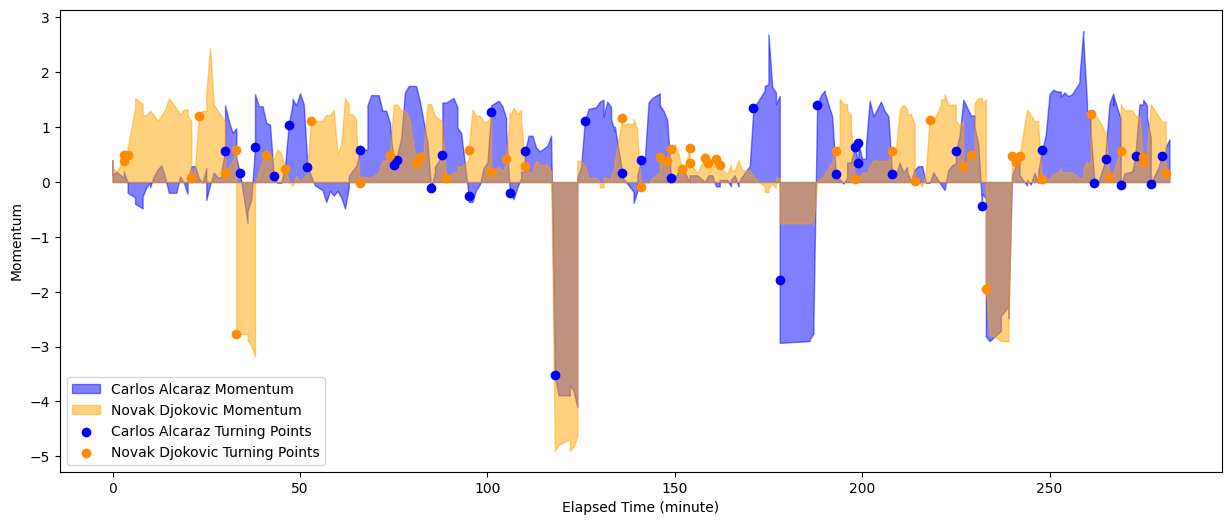

In [65]:
import statsmodels.api as sm
from statsmodels.tsa.arima.model import ARIMA
def arima_detection(series):
    model = ARIMA(series, order=(1, 0, 0))  # 设置ARIMA模型的阶数
    model_fit = model.fit()  # 拟合ARIMA模型
    predicted_values = model_fit.predict(typ='levels')  # 预测序列的值
    print("ARIMA model AIC: ", model_fit.aic)
    print("ARIMA model BIC: ", model_fit.bic)
    return predicted_values
p1_predicted = arima_detection(match_data['p1_momentum'])
p2_predicted = arima_detection(match_data['p2_momentum'])
p1_turning_points = cumsum_detection(p1_predicted)
p2_turning_points = cumsum_detection(p2_predicted)

# 绘制势头变化图
plt.figure(figsize=(15,6))
# 绘制球员1的势头变化
plt.fill_between(elapsed_m, p1_predicted, color='blue', alpha=0.5, label=match_data['player1'].iloc[0] + " Momentum")
# 绘制球员2的势头变化
plt.fill_between(elapsed_m, p2_predicted, color='orange', alpha=0.5, label=match_data['player2'].iloc[0] + " Momentum")

# 标记转折点
plt.scatter(elapsed_m.iloc[p1_turning_points], p1_predicted.iloc[p1_turning_points], color='b', label=match_data['player1'].iloc[0] +' Turning Points', zorder=5)
plt.scatter(elapsed_m.iloc[p2_turning_points], p2_predicted.iloc[p2_turning_points], color='darkorange', label=match_data['player2'].iloc[0] +' Turning Points', zorder=5)
# 设置标题和坐标轴标签
# plt.title('Momentum Change with Area Chart Throughout the Match')
plt.xlabel('Elapsed Time (minute)')
plt.ylabel('Momentum')
plt.legend(loc="lower left")


ARIMA model AIC:  692.2123346456964
ARIMA model BIC:  707.4568986176032
ARIMA model AIC:  723.9031211526344
ARIMA model BIC:  739.1476851245412
Residual ADF Statistic: -7.055398
Residual p-value: 0.000000
Residual Critical Values:
	1%: -3.460
	5%: -2.875
	10%: -2.574
RMSE: 1.231946099457734
MAE: 0.870743881057628


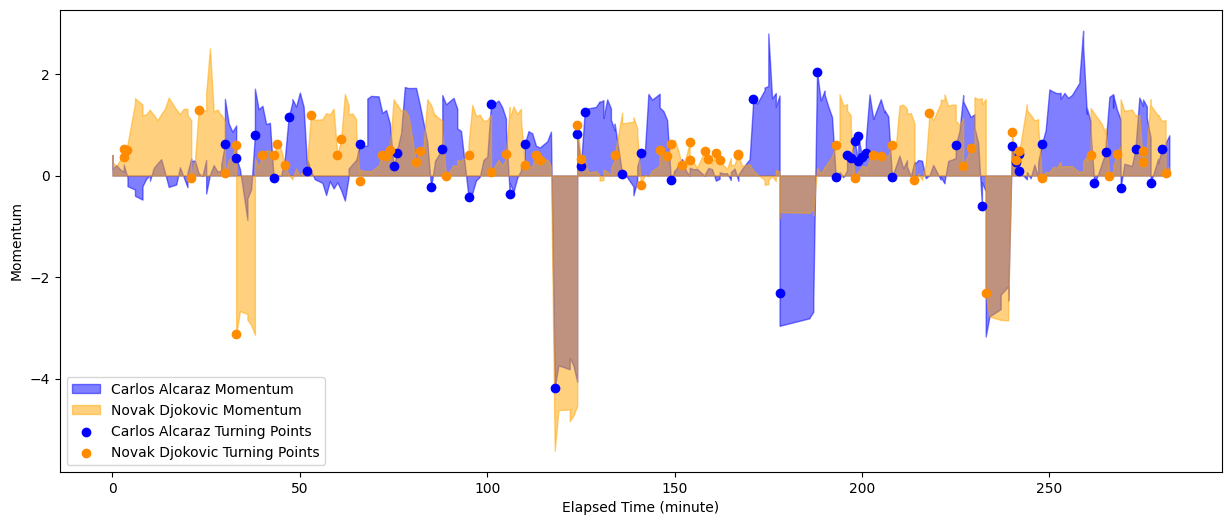

In [83]:
import statsmodels.api as sm
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np
import statsmodels.tsa.stattools as ts
def arima_detection(series):
    model = ARIMA(series, order=(1, 0, 1))  # 设置ARIMA模型的阶数
    model_fit = model.fit()  # 拟合ARIMA模型
    predicted_values = model_fit.predict(typ='levels')  # 预测序列的值

    # 输出模型的AIC和BIC值
    print("ARIMA model AIC: ", model_fit.aic)
    print("ARIMA model BIC: ", model_fit.bic)

    return predicted_values

p1_predicted = arima_detection(match_data['p1_momentum'])
p2_predicted = arima_detection(match_data['p2_momentum'])
p1_turning_points = cumsum_detection(p1_predicted)
p2_turning_points = cumsum_detection(p2_predicted)

# 绘制势头变化图
plt.figure(figsize=(15,6))
# 绘制球员1的势头变化
plt.fill_between(elapsed_m, p1_predicted, color='blue', alpha=0.5, label=match_data['player1'].iloc[0] + " Momentum")
# 绘制球员2的势头变化
plt.fill_between(elapsed_m, p2_predicted, color='orange', alpha=0.5, label=match_data['player2'].iloc[0] + " Momentum")

# 标记转折点
plt.scatter(elapsed_m.iloc[p1_turning_points], p1_predicted.iloc[p1_turning_points], color='b', label=match_data['player1'].iloc[0] +' Turning Points', zorder=5)
plt.scatter(elapsed_m.iloc[p2_turning_points], p2_predicted.iloc[p2_turning_points], color='darkorange', label=match_data['player2'].iloc[0] +' Turning Points', zorder=5)
# 设置标题和坐标轴标签
# plt.title('Momentum  with Area Chart Throughout the Match')
plt.xlabel('Elapsed Time (minute)')
plt.ylabel('Momentum')

# 在训练集上评估 ARIMA 模型的性能
train_data = match_data['p1_momentum'][:int(0.7*len(match_data['p1_momentum']))]
test_data = match_data['p1_momentum'][int(0.7*len(match_data['p1_momentum'])):]
test_data = test_data.reset_index(drop=True)

model = ARIMA(train_data, order=(1, 0, 0))
model_fit = model.fit()
model_fit = model.fit()

# 进行差分性检验（ADF检验）
result = ts.adfuller(model_fit.resid)
print('Residual ADF Statistic: %f' % result[0])
print('Residual p-value: %f' % result[1])
print('Residual Critical Values:')
for key, value in result[4].items():
    print('\t%s: %.3f' % (key, value))

predictions = model_fit.forecast(steps=len(test_data)).iloc[:len(test_data)]

# 计算均方根误差（RMSE）
rmse = np.sqrt(mean_squared_error(test_data, predictions))

# 计算平均绝对误差（MAE）
mae = mean_absolute_error(test_data, predictions)

print("RMSE:", rmse)
print("MAE:", mae)
model_fit = model.fit()  # 拟合ARIMA模型
plt.legend(loc="lower left")



检测转折点，即比赛结果可能发生显著变化的关键球点，可以通过分析球员势头的变化来实现。一种方法是寻找势头变化的显著点，即从连续失分到连续得分的转变，或者反之。这可以通过检测势头时间序列中的变化点来实现。

在这里，我们可以使用差异性检验算法，比如CUMSUM（累积和）检测算法，来确定势头中的转折点。CUMSUM检测算法通过累积序列中的正负变化来识别潜在的转变点。以下是实现此算法的步骤：

1. **计算势头差分序列**：首先，我们需要计算每位球员势头的差分序列，即当前点的势头与前一点的势头之差。
2. **应用CUMSUM算法**：然后，对势头差分序列应用CUMSUM算法，寻找势头发生显著变化的点。
3. **识别转折点**：基于CUMSUM结果，我们可以确定哪些点是潜在的转折点，即比赛中势头发生显著变化的时刻。

下面，我们将根据上述步骤编写代码实现检测转折点的方法。



In [37]:
def cumsum_detection(series):
    """
    CUMSUM检测算法实现，用于检测序列中的转折点。
    :param series: 一维数据序列 (Pandas Series)
    :return: 转折点的索引列表
    """
    # 计算差分序列
    diff_series = series.diff().fillna(0)  # 用0填充NaN值
    
    # 计算累积和
    cumsum_series = diff_series.cumsum()
    
    # 识别转折点：当累积和重新穿过零点时，认为是一个转折点
    turning_points = []
    for i in range(1, len(cumsum_series)):
        # 如果累积和的符号与前一个不同，则认为是转折点
        if cumsum_series[i] * cumsum_series[i-1] < 0:
            turning_points.append(i)
    
    return turning_points

In [38]:
match_data['p1_momentum']=pd.DataFrame(p1_momentum)
match_data['p2_momentum']=pd.DataFrame(p2_momentum)
# p1_turning_points = cumsum_detection(match_data['p1_momentum'])
# p2_turning_points = cumsum_detection(match_data['p2_momentum'])
p1_turning_points = arima_detection(match_data['p1_momentum'])
p2_turning_points = arima_detection(match_data['p2_momentum'])

ARIMA model AIC:  692.2123346456964
ARIMA model BIC:  707.4568986176032
ARIMA model AIC:  723.9031211526344
ARIMA model BIC:  739.1476851245412


In [39]:
from scipy.stats import norm

def runs_test(sequence):
    """
    游程检验，判断序列随机性。
    :param sequence: 输入的序列 (list or np.array)
    :return: Z统计量和p值
    """
    # 将序列分为两类
    median_value = np.median(sequence)
    binary_sequence = [1 if x > median_value else 0 for x in sequence]
    
    # 计算游程数量
    runs = 1  # 至少有一个游程
    for i in range(1, len(binary_sequence)):
        if binary_sequence[i] != binary_sequence[i-1]:
            runs += 1
    
    # 计算期望的游程数量和标准差
    n1 = binary_sequence.count(1)
    n2 = binary_sequence.count(0)
    expected_runs = 2 * n1 * n2 / (n1 + n2) + 1
    variance = (expected_runs - 1) * (expected_runs - 2) / (n1 + n2 - 1)
    
    # 计算Z统计量
    Z = (runs - expected_runs) / np.sqrt(variance)
    
    # 计算p值
    p_value = 2 * (1 - norm.cdf(abs(Z)))  # 双尾检验
    
    return Z, p_value

runs_test( p1_momentum)



(-13.809417562880043, 0.0)

In [121]:
runs_test( p2_momentum)

(-11.71872679580918, 0.0)

In [122]:
runs_test( p1_turning_points)

(-6.00416522091123, 1.923187831209816e-09)

In [123]:
runs_test( p2_turning_points)

(-7.812249995999872, 5.551115123125783e-15)